#  Evolutionary Multiple-objective Optimization (part for 4.0)

- This script is for those who want to improve their final grade from 3.0 to 4.0. 
- Your task is to implement any one evolutionary algorithm for multiple-objective optimization introduced during the lecture (NSGA-II/NSGA-III/MOEA/D; except for NSGA).
- Note that it has to be your implementation (using external libraries is forbidden; EXCEPTION: you can use the JECDM framework: https://jecdm.cs.put.poznan.pl -- but it is a relatively complex software, and much effort must be spent to understand how to use it).
- The problem to be solved is the portfolio optimization tackled during lab 1.
- You can use the same data and price predictions as you made for lab 1 (Bundle1.zip) or update them accordingly to the next stage if you participate in the portfolio game (it is up to you).
- Apart from the two-objective scenario, tackle also a three-objective one. As for the third objective, think about some reasonable risk-measure. E.g., you can maximize the number of non-zero weights, which should refer to minimizing risk by diversifying investments.
- Perform experimental evaluation of your implementation. You can use, e.g., the IDG or the HV metric to quantify the quality of populations constructed by the method.
- The experimental evaluation should be "reasonably extensive." E.g., run your method multiple times and average the results, show average convergence plots, do the sensitivity analysis (just four combinations of population size/generations will be enough), and depict some final populations. Also, compare the populations (only for 2D scenarios) with those generated by the ECM or WSM algorithm. Note that ECM and WSM already generate Pareto optimal solutions, so these can be considered good benchmarks for comparison.
- You can report your results here, i.e., in the jupyter notebook. You do not need to prepare any pdf report, etc. 

This notebook is the implementation of the MOAE/D genetic algorithm for multi-objective optimization. Additionally, a comprehensive comparison of the algorithm's convergence, and 

# Introduction

Classical methods for Markowitz portfolio optimization, like quadratic programming or mean-variance analysis, often struggle with real-world constraints, multiple objectives, and computational efficiency when handling large datasets.  

MOAE/D (Multi-Objective Adaptive Evolutionary Algorithm based on Decomposition) offers several key advantages:  

- **Better Handling of Multiple Objectives**: Unlike classical approaches that rely on scalarization, MOAE/D effectively finds a diverse set of Pareto-optimal solutions, giving investors more flexibility.  
- **Robustness to Complex Constraints**: Real-world portfolios often have constraints (e.g., cardinality, turnover limits) that classical methods handle poorly. MOAE/D naturally integrates these constraints.  
- **Scalability and Adaptability**: Evolutionary algorithms like MOAE/D can efficiently explore high-dimensional search spaces, making them suitable for large-scale portfolio optimization problems.  
- **Avoidance of Local Optima**: Traditional optimization techniques can get stuck in local optima, whereas MOAE/D, using evolutionary search, explores a broader solution space for better results.  

MOAE/D enhances the Markowitz framework by offering a more flexible, robust, and scalable approach to portfolio optimization, particularly in complex and dynamic financial environments.  


## Imports and Declarations

In [1]:
from utils.MOO_utilities import *

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

## Data

The data shows 20 ficticious stocks over time, the regression values are taken from the first notebook and were calculated using Linear Regression.

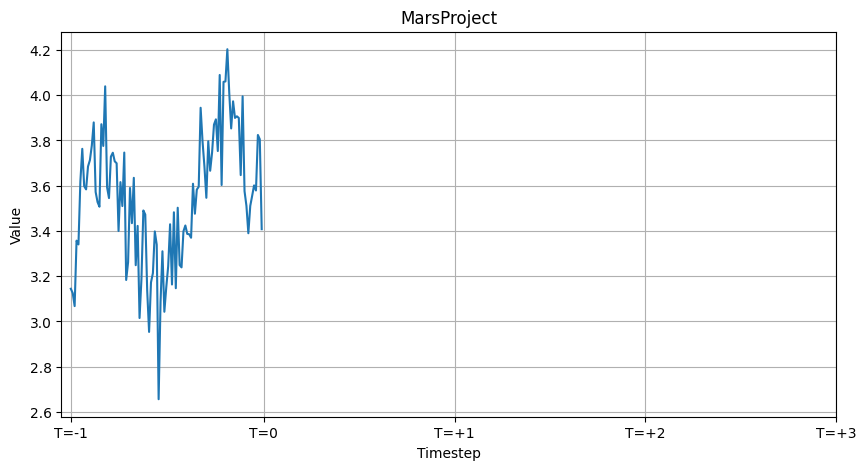

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

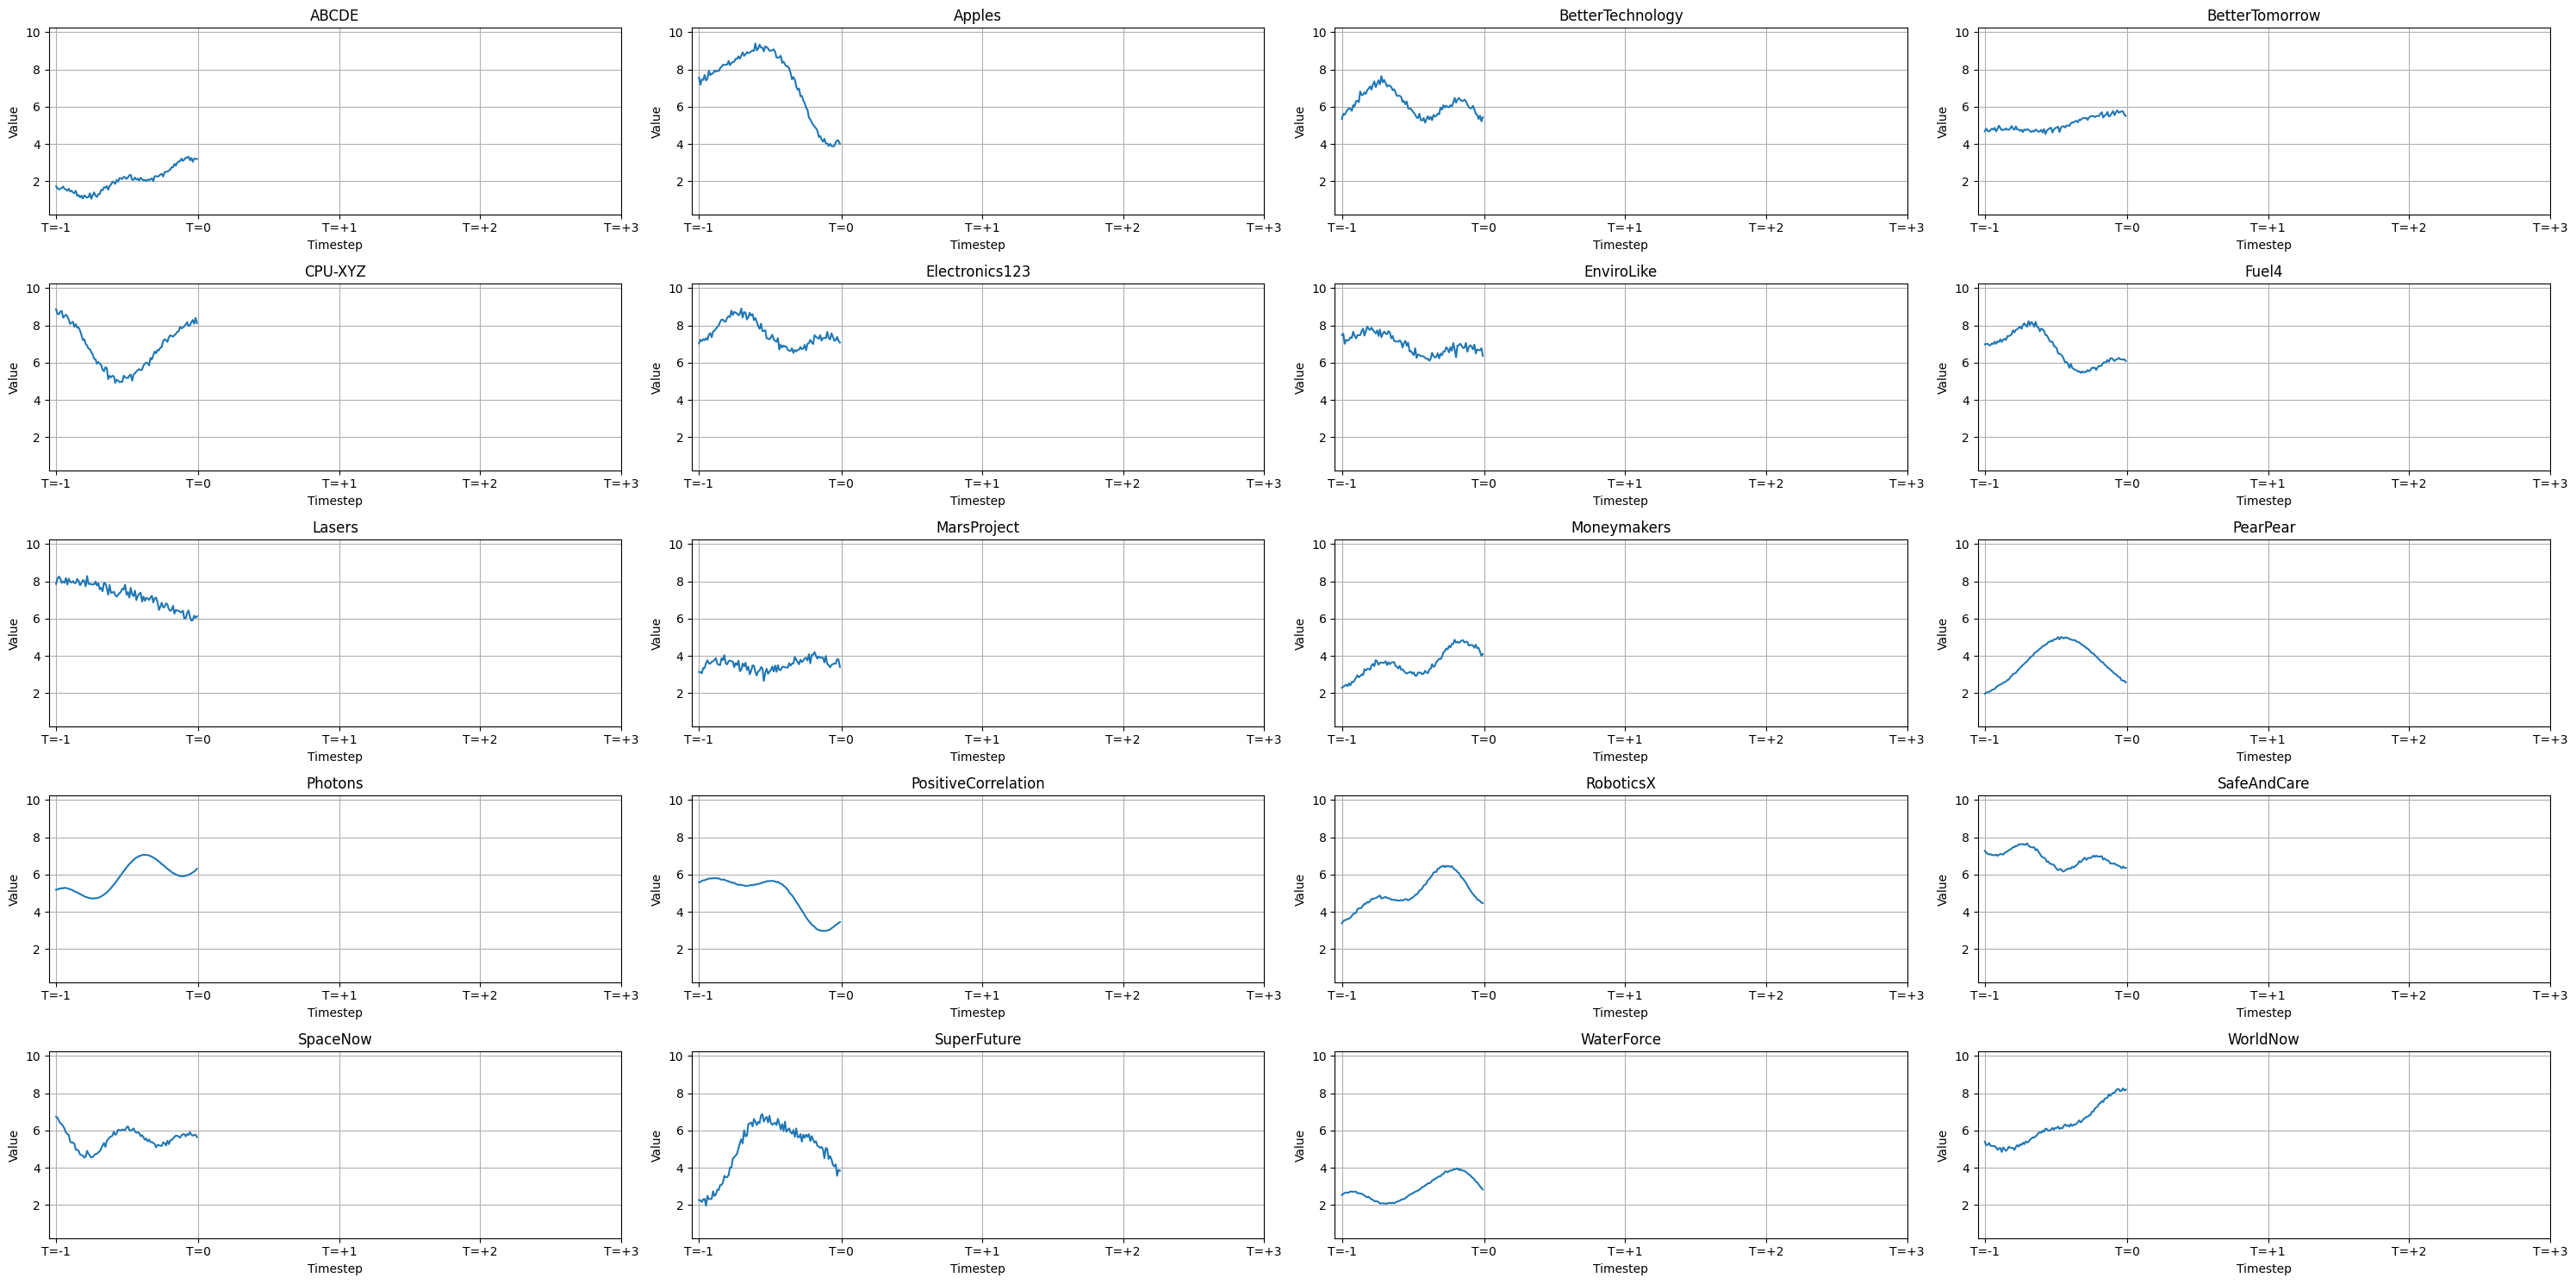

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

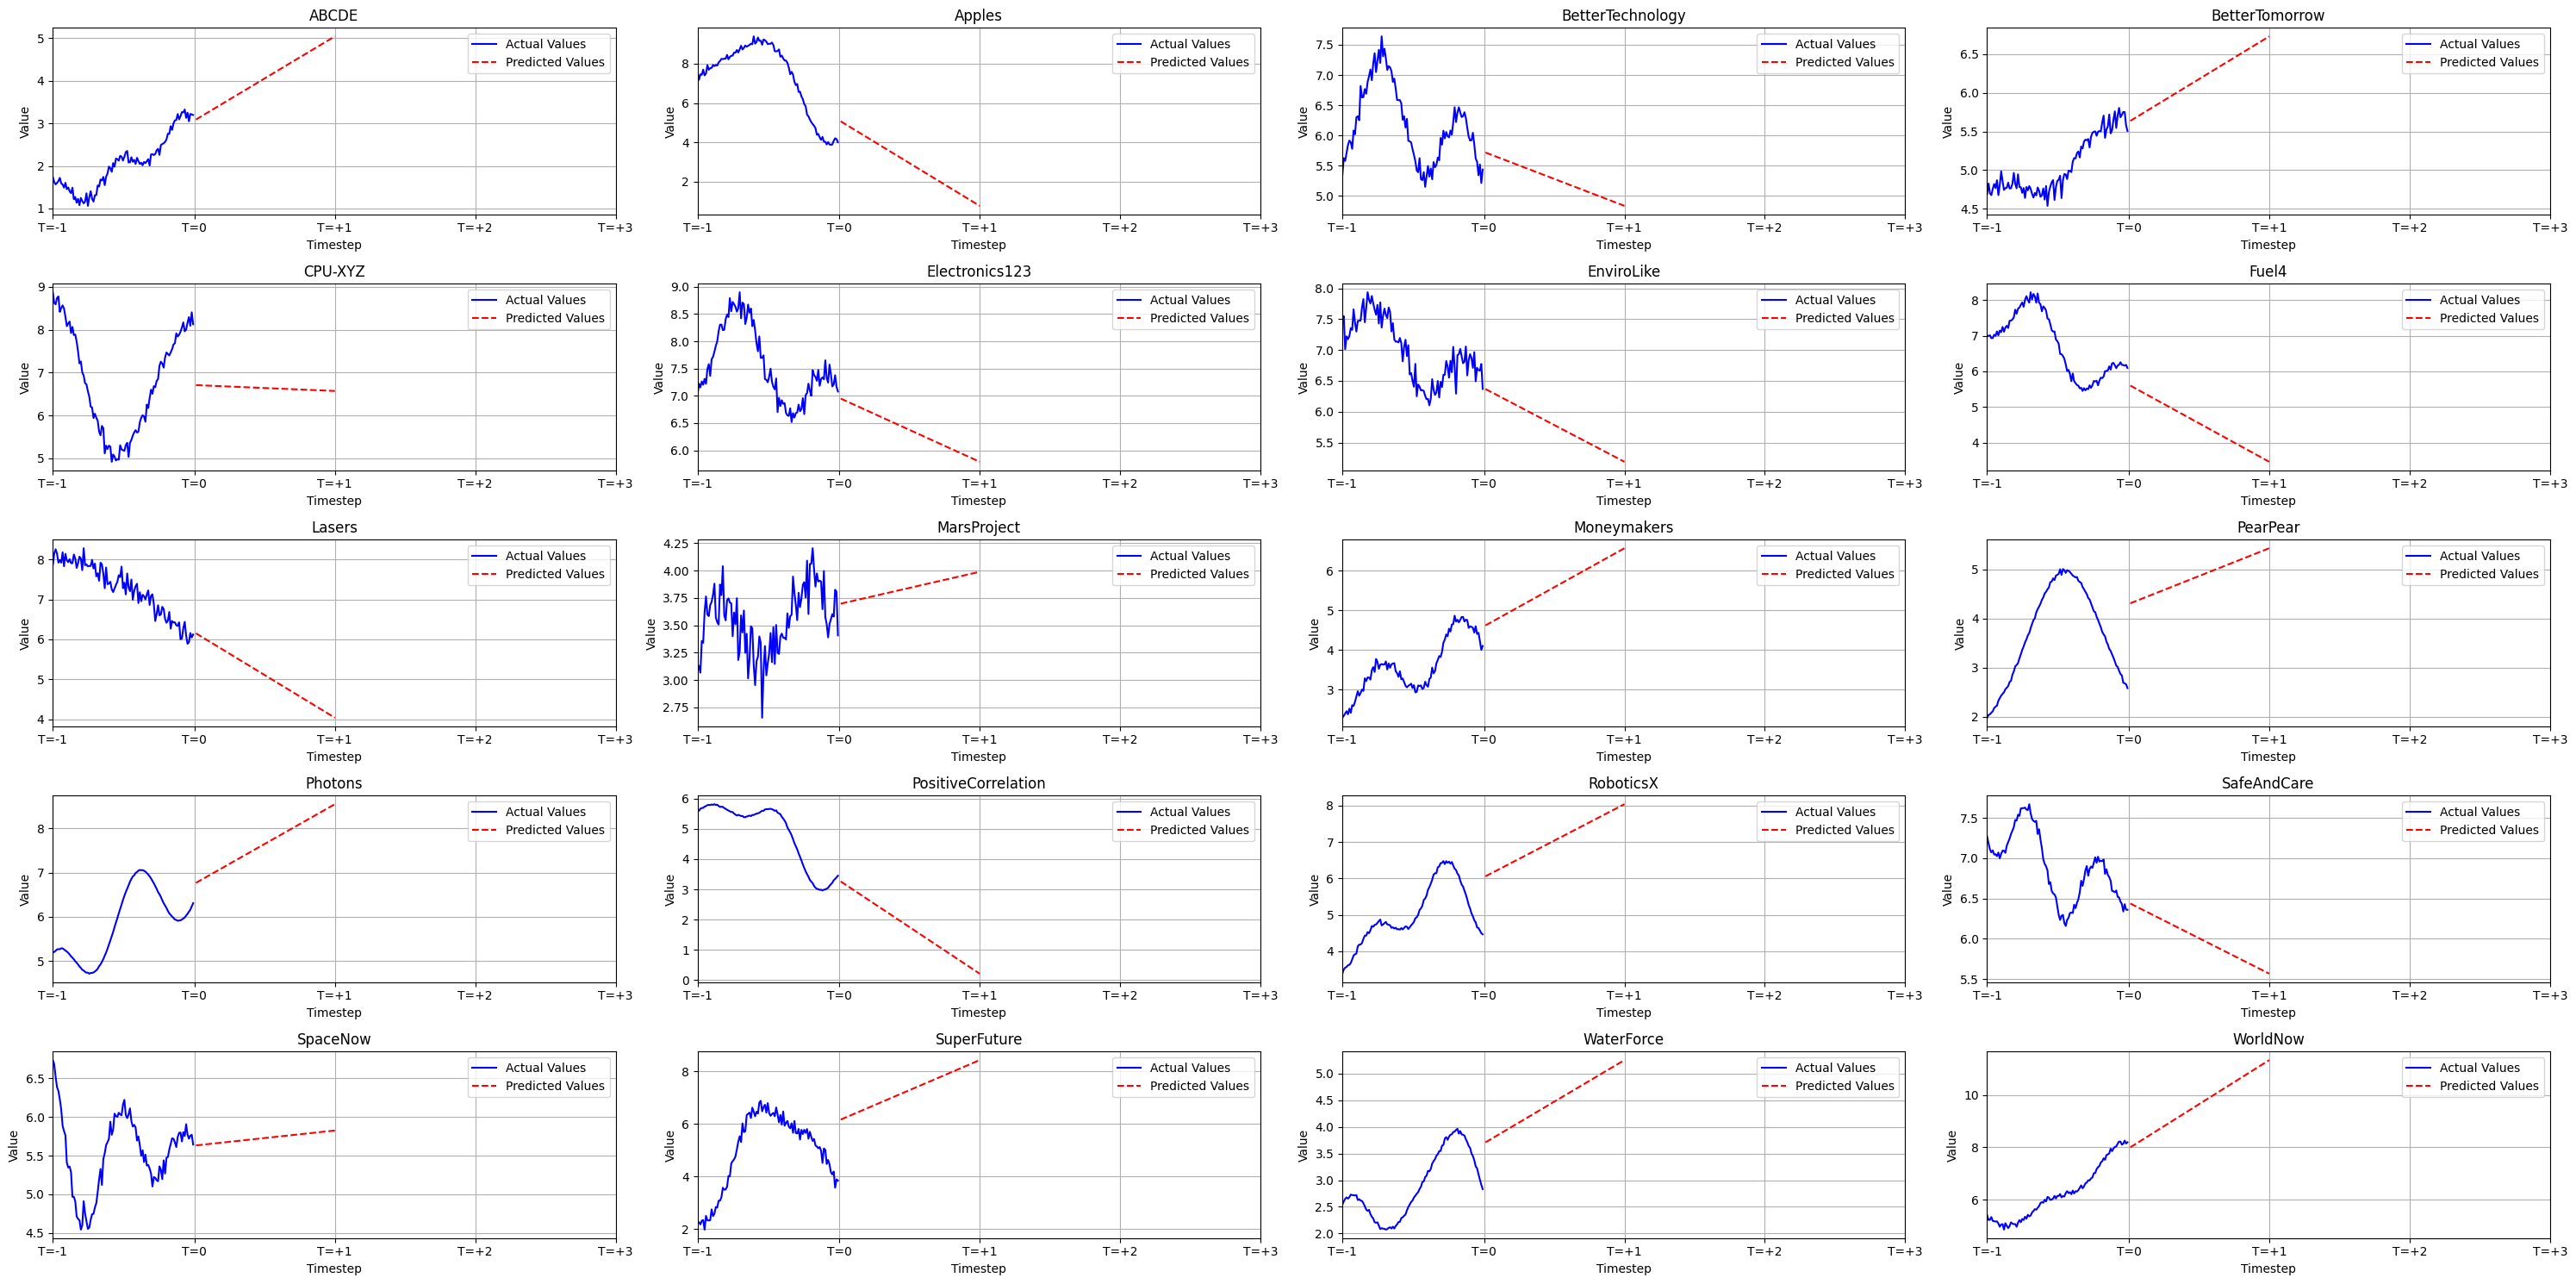

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

In [6]:
risks = RMC.get_covariance_matrix()

## MOAE/D

## 2D - Case

In [7]:
GS = GeneticSolver(data, linear_predictions, risks, population_size=50, mutation_probability=0.8, weight_size=20, num_dimensions=2)
population = GS.genetic_optimize(generations=150, neighborhood_size=5)
solutions = GS.get_solutions_from_population(population)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [8]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,1.059206,0.732944,0.101877,0.000639,0.001491,0.000731,0.000419,0.000696,0.737309,0.000270,...,0.001892,0.000163,0.001659,0.000393,0.022635,0.001200,0.116664,0.001021,0.006429,1.0
1,0.961657,0.372361,0.058251,0.000934,0.001627,0.001405,0.000833,0.001049,0.455026,0.000910,...,0.004603,0.002363,0.002856,0.001211,0.018317,0.001207,0.432600,0.002933,0.006479,1.0
2,0.945508,0.341260,0.037172,0.001228,0.001805,0.001969,0.001228,0.001417,0.456868,0.001225,...,0.006831,0.004410,0.003605,0.001929,0.009776,0.001227,0.448187,0.004526,0.007186,1.0
3,1.004501,0.477781,0.022363,0.000689,0.001559,0.000899,0.000472,0.000743,0.640213,0.000326,...,0.002666,0.000304,0.002302,0.000583,0.025501,0.001278,0.285921,0.001734,0.006403,1.0
4,0.974486,0.391296,0.049888,0.000763,0.001365,0.001129,0.000666,0.000854,0.496069,0.000661,...,0.003652,0.001798,0.002320,0.000949,0.016173,0.001023,0.408902,0.002283,0.005455,1.0
5,1.020575,0.528008,0.044022,0.000547,0.001236,0.000713,0.000376,0.000589,0.658630,0.000264,...,0.002093,0.000268,0.001806,0.000455,0.020262,0.001011,0.256646,0.001286,0.005053,1.0
6,0.668277,0.125517,0.021353,0.007295,0.006924,0.027567,0.015134,0.009657,0.247148,0.008033,...,0.013630,0.013723,0.017068,0.031356,0.013667,0.006904,0.448050,0.006645,0.011070,1.0
7,0.647972,0.108445,0.023105,0.005017,0.005029,0.125565,0.008227,0.006132,0.191470,0.006100,...,0.020832,0.011945,0.005765,0.013372,0.011242,0.002927,0.498731,0.005115,0.010716,1.0
8,1.162952,1.848335,0.928873,0.000605,0.001425,0.000588,0.000391,0.000513,0.023461,0.000244,...,0.001434,0.000089,0.001141,0.000341,0.026518,0.001119,0.002951,0.000385,0.006660,1.0
9,0.866841,0.258251,0.046128,0.002463,0.003092,0.004050,0.002957,0.002876,0.258352,0.002777,...,0.012254,0.008004,0.004723,0.004300,0.013679,0.001754,0.597431,0.006121,0.010633,1.0


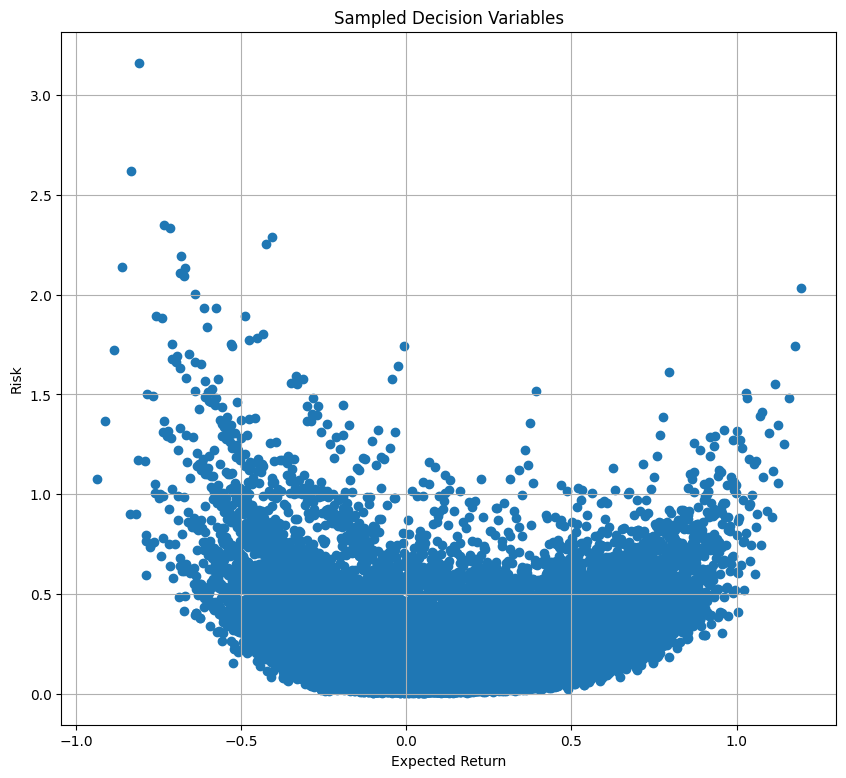

In [9]:
GS.plot_sampled_decision_variables(20, 0.2)

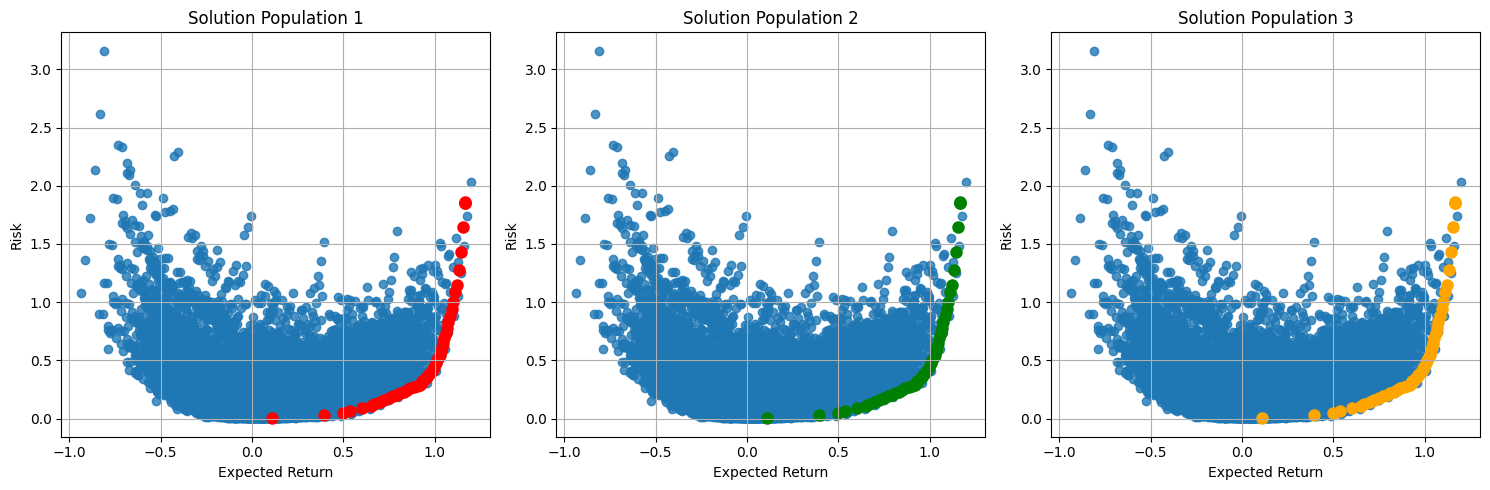

In [10]:
GS.plot_many(solutions, solutions, solutions)

### 3D-Case

In case of the 3D-case an additional objective to be minimized was defined as number of very small weights ( <0.01 ) in the final decision vector.

In [11]:
GS = GeneticSolver(data, linear_predictions, risks, population_size=150, mutation_probability=0.8, weight_size=20, num_dimensions=3)
population = GS.genetic_optimize(generations=150, neighborhood_size=5)
solutions = GS.get_solutions_from_population_3D(population)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


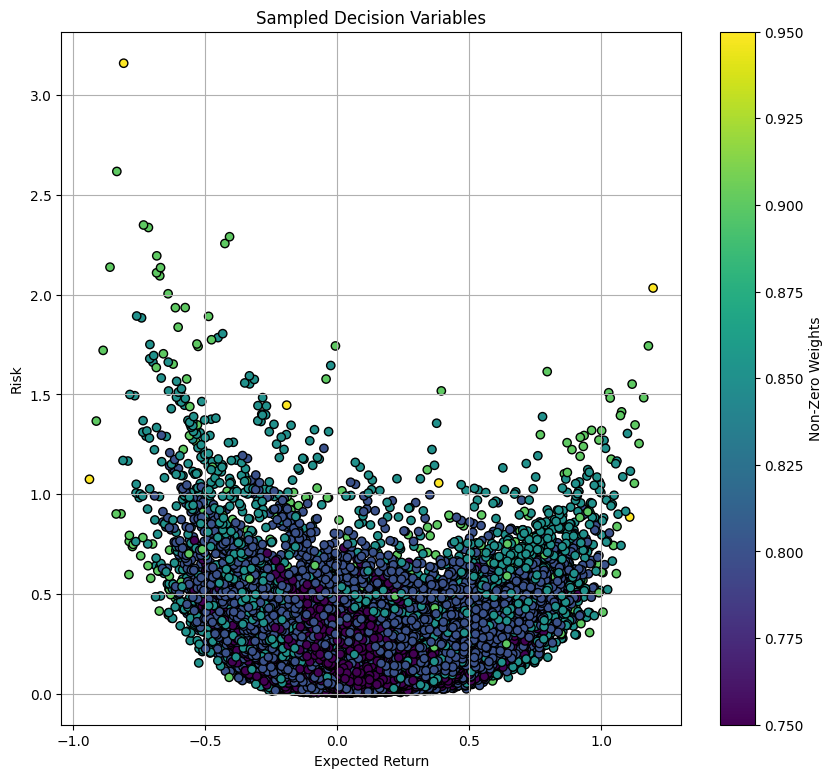

In [12]:
GS.plot_sampled_3D()

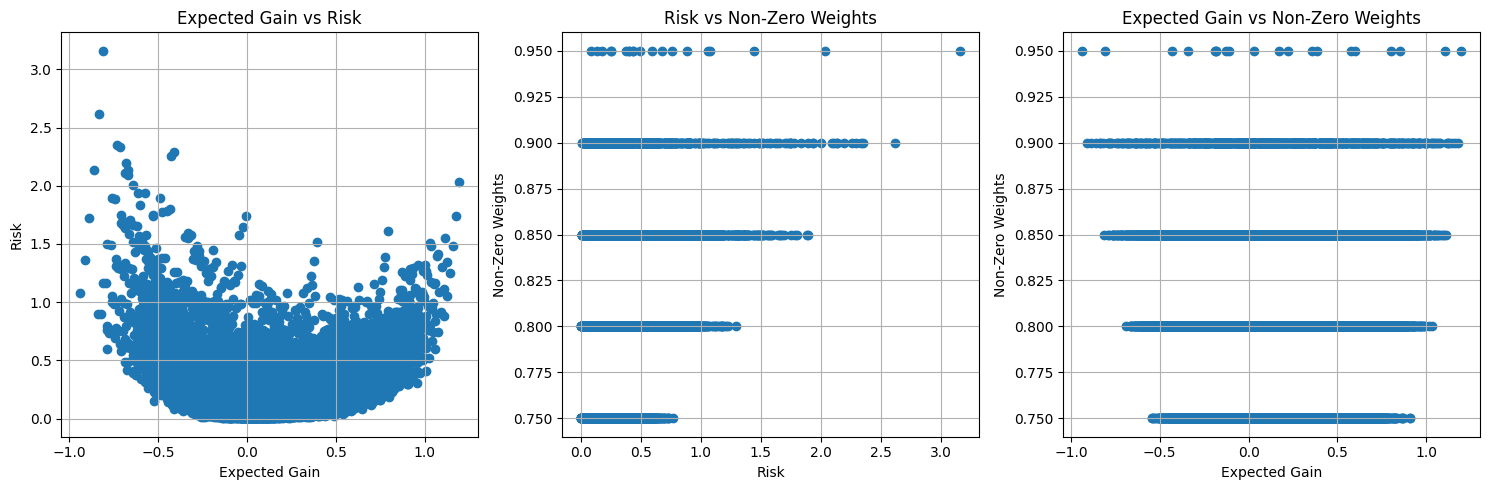

In [13]:
GS.plot_sampled_3D(color=False)

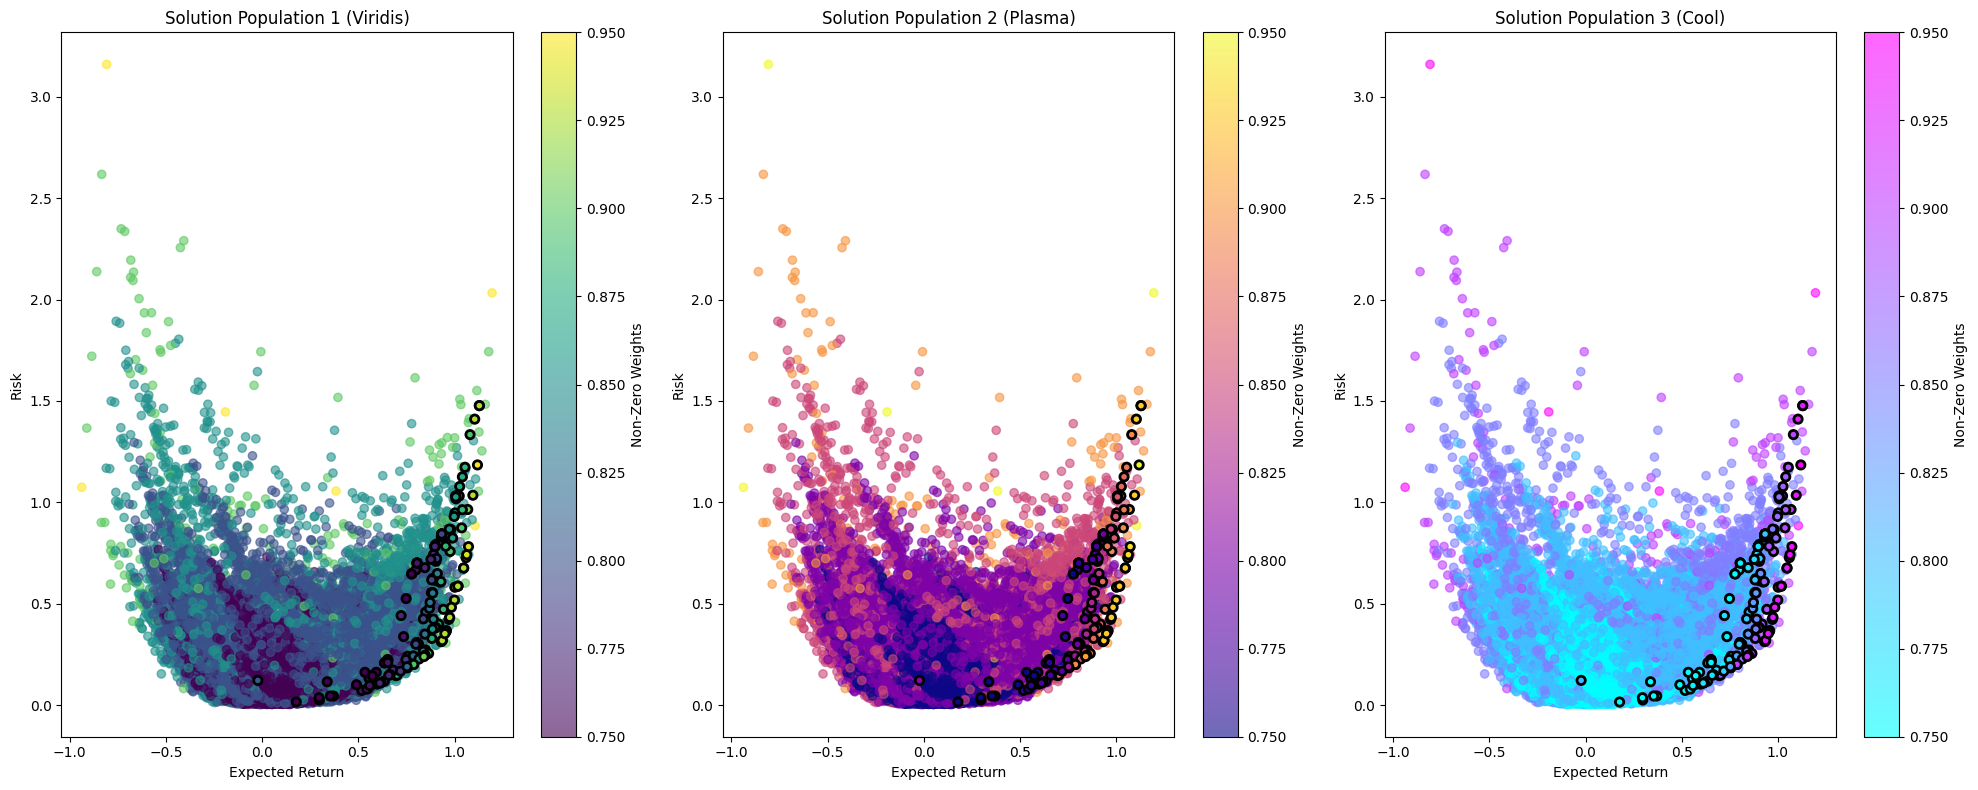

In [14]:
GS.plot_many_3D(solutions, solutions, solutions)

In [15]:
GS.plot_front_real_3D(solutions, color=True, colorscale="aggrnyl")

In [16]:
GS.plot_front_real_3D(solutions, color=True, colorscale="agsunset")

In [17]:
GS.plot_front_real_3D(solutions, color=True, colorscale="pubu")

In [18]:
GER = GeneticExperimentRunner()
GER.get_convergence(data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:98: RuntimeWarning:

overflow encountered in cast

d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:244: RuntimeWarning:

overflow encountered in cast

d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:258: RuntimeWarning:

overflow encountered in cast



     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

d:\MOO\MOO\utils\MOO_utilities.py:1515: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1515: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1515: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



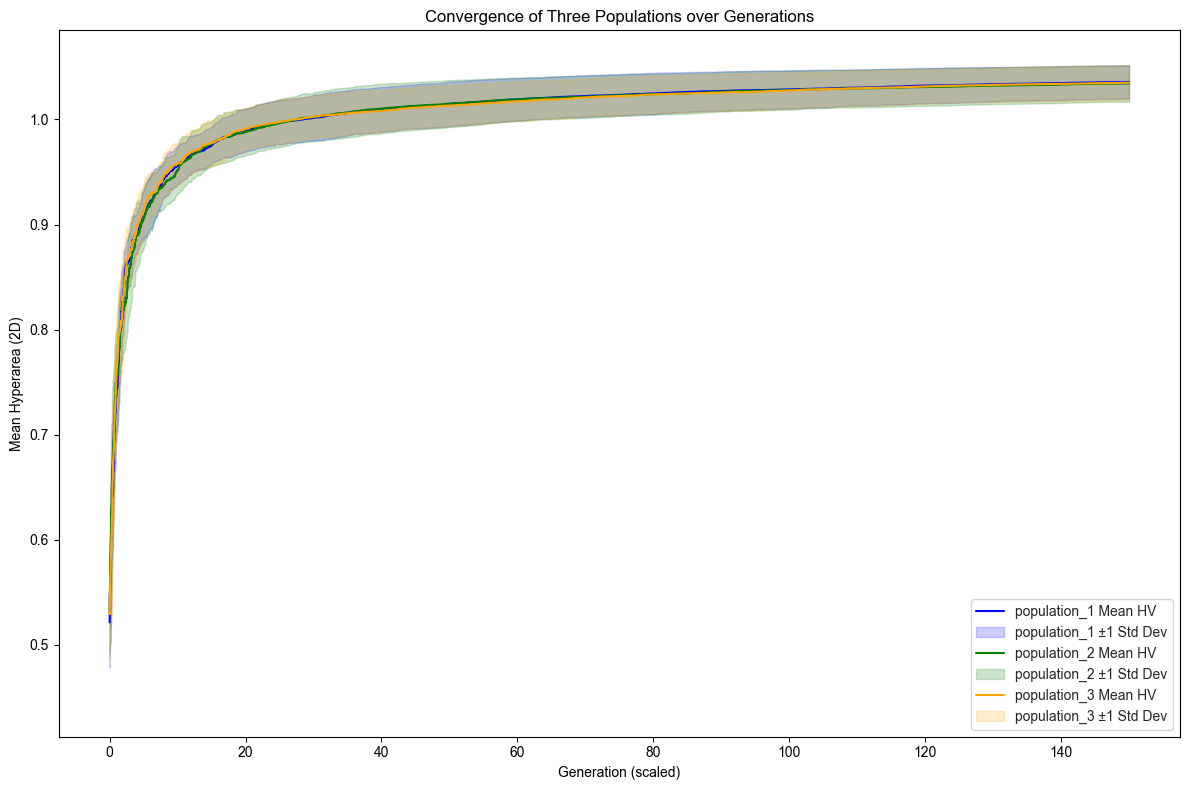

In [19]:
GER.plot_convergence()

In [20]:
GER.get_genetic_vs_classic(data, linear_predictions, risks, num_retries=10)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

## MOAE/D VS Classical Methods

d:\MOO\MOO\utils\MOO_utilities.py:1411: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1411: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1411: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



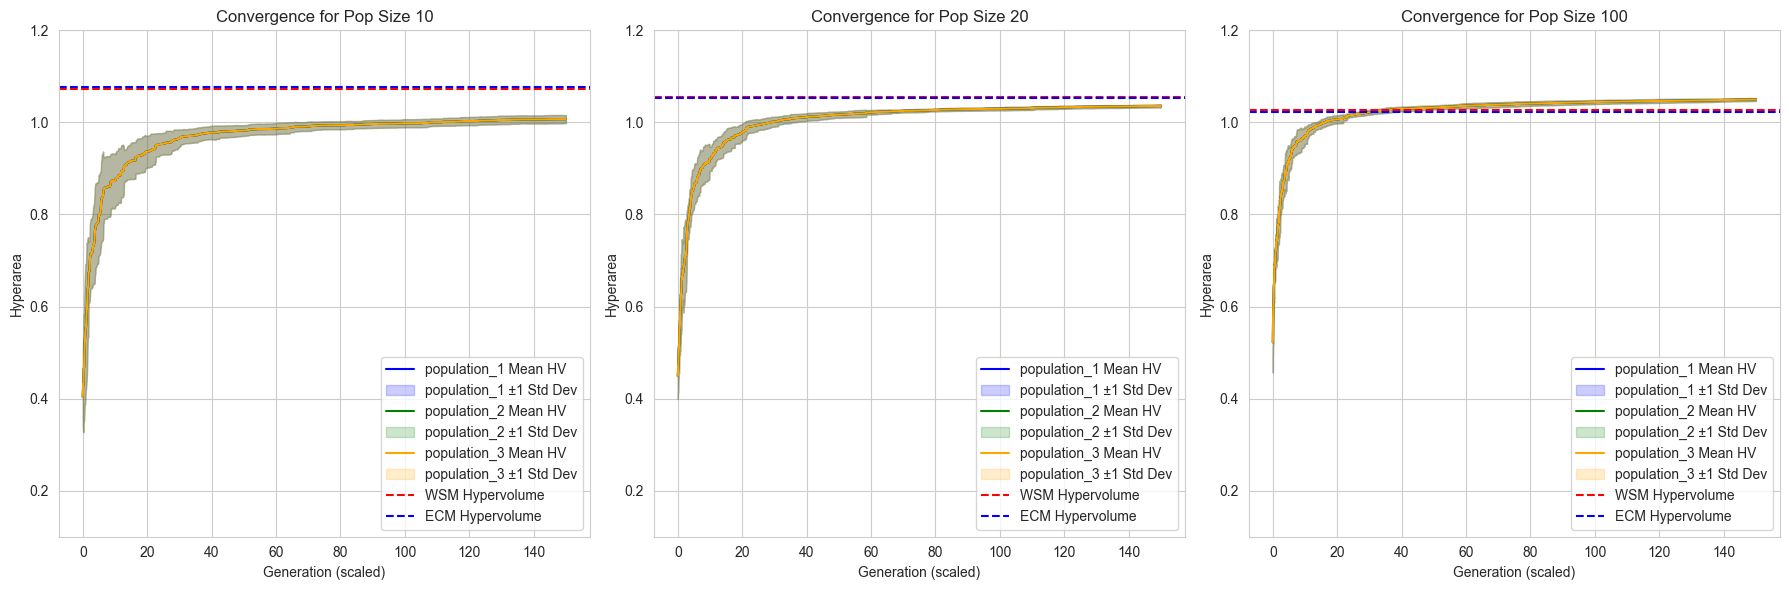

In [21]:
GER.plot_genetic_vs_classic()

## Conclusions


1. **Smooth Convergence**  
   - The algorithm exhibits a smooth and steady convergence across different population sizes.  
   - Rapid initial improvements are observed, followed by gradual plateauing as generations progress.  

2. **Small Standard Deviation**  
   - The shaded region representing ±1 standard deviation is relatively narrow.  
   - This indicates consistent performance and stable convergence across multiple runs.  

3. **Performance of MOAE/D**  
   - The final hypervolume achieved by the genetic algorithm (MOAE/D) approaches or surpasses the reference hypervolumes (WSM and ECM).  
   - This demonstrates its effectiveness in multi-objective optimization.  

4. **Impact of Population Size**  
   - Larger population sizes (e.g., 100) result in faster convergence and better final performance.  
   - A sufficiently large population enhances exploration and solution quality.  

5. **Comparison to Classical Methods**  
   - The genetic algorithm reaches or exceeds the hypervolume of classical methods (WSM, ECM).  
   - This highlights its superior ability to approximate the Pareto front, particularly in complex problem spaces.  
